# Demand Forecasting

## Data and Libraries Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import os
from pathlib import Path
from dotenv import load_dotenv

from sqlalchemy import create_engine, text

import warnings
warnings.filterwarnings('ignore')

In [2]:
env_path = r"C:\Users\Rano's PC\Machine\github_repo_cloned\india-logistics-hub-optimizer\.env"
load_dotenv(dotenv_path=env_path) 

HOST = os.getenv("DB_HOST")
USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
OUTPUT_DIR = os.getenv("OUTPUT_DIR")

In [3]:
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}")


def sql(query, engine = engine):
    with engine.connect() as conn:
        df = pd.read_sql(text(query),conn)
    return df

In [4]:
query = "select * from forecasting_data"

data = sql(query=query,engine=engine)

In [5]:
data.head()

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
0,andaman and nicobar,2018-07,7499.0,194.66,7499.0,194.66
1,andhra pradesh,2018-07,1931596.0,66363.08,1931596.0,66363.08
2,arunachal pradesh,2018-07,19147.0,394.15,19147.0,394.15
3,assam,2018-07,601740.0,17874.21,601740.0,17874.21
4,bihar,2018-07,616137.0,18787.14,616137.0,18787.14


## Initial Data Check

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   state          3650 non-null   object 
 1   date           3650 non-null   object 
 2   bill_volume    3650 non-null   float64
 3   bill_amount    3650 non-null   float64
 4   avg_bill_3m    3650 non-null   float64
 5   avg_amount_3m  3650 non-null   float64
dtypes: float64(4), object(2)
memory usage: 171.2+ KB


In [7]:
data['state'].nunique()

38

In [8]:
data['state'].unique()

array(['andaman and nicobar', 'andhra pradesh', 'arunachal pradesh',
       'assam', 'bihar', 'chandigarh', 'chhattisgarh',
       'dadra and nagar haveli', 'daman and diu', 'delhi', 'goa',
       'gujarat', 'haryana', 'himachal pradesh', 'jammu and kashmir',
       'jharkhand', 'karnataka', 'kerala', 'lakshadweep',
       'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram',
       'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan',
       'sikkim', 'tamil nadu', 'telangana', 'tripura', 'uttar pradesh',
       'uttarakhand', 'west bengal', 'other territory', 'ladakh'],
      dtype=object)

In [9]:
data['date']

0       2018-07
1       2018-07
2       2018-07
3       2018-07
4       2018-07
         ...   
3645    2026-07
3646    2026-07
3647    2026-07
3648    2026-07
3649    2026-07
Name: date, Length: 3650, dtype: object

In [10]:
data['date']=pd.to_datetime(data['date'],format="%Y-%m").dt.to_period("M")

In [11]:
data.sample(5)

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
1943,other territory,2022-10,12310.0,3403.61,12423.33,3720.77
3591,kerala,2026-06,4086610.0,294602.40,3947644.33,181921.16
2522,uttarakhand,2024-01,1759741.0,52145.13,1722568.33,50134.48
1132,jammu and kashmir,2021-01,312330.0,8818.00,355851.67,9239.87
2700,mizoram,2024-06,30402.0,538.27,31845.00,592.42


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   state          3650 non-null   object   
 1   date           3650 non-null   period[M]
 2   bill_volume    3650 non-null   float64  
 3   bill_amount    3650 non-null   float64  
 4   avg_bill_3m    3650 non-null   float64  
 5   avg_amount_3m  3650 non-null   float64  
dtypes: float64(4), object(1), period[M](1)
memory usage: 171.2+ KB


In [13]:
data.isnull().sum()

state            0
date             0
bill_volume      0
bill_amount      0
avg_bill_3m      0
avg_amount_3m    0
dtype: int64

In [14]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
bill_volume,3650.0,2.885065e+06,4.335539e+06,20.00,63548.5000,952044.000,3.877952e+06,27217002.00
bill_amount,3650.0,8.255815e+04,1.216688e+05,0.38,2669.0000,33347.620,1.171698e+05,851046.04
avg_bill_3m,3650.0,2.851899e+06,4.266516e+06,24.00,64748.6675,971766.665,3.814462e+06,26612414.67
avg_amount_3m,3650.0,8.159119e+04,1.194640e+05,0.98,2681.3400,33650.645,1.173938e+05,817054.51


In [15]:
data= data.sort_values('date')

In [16]:
data['date']=data['date'].dt.to_timestamp()

## Visualization

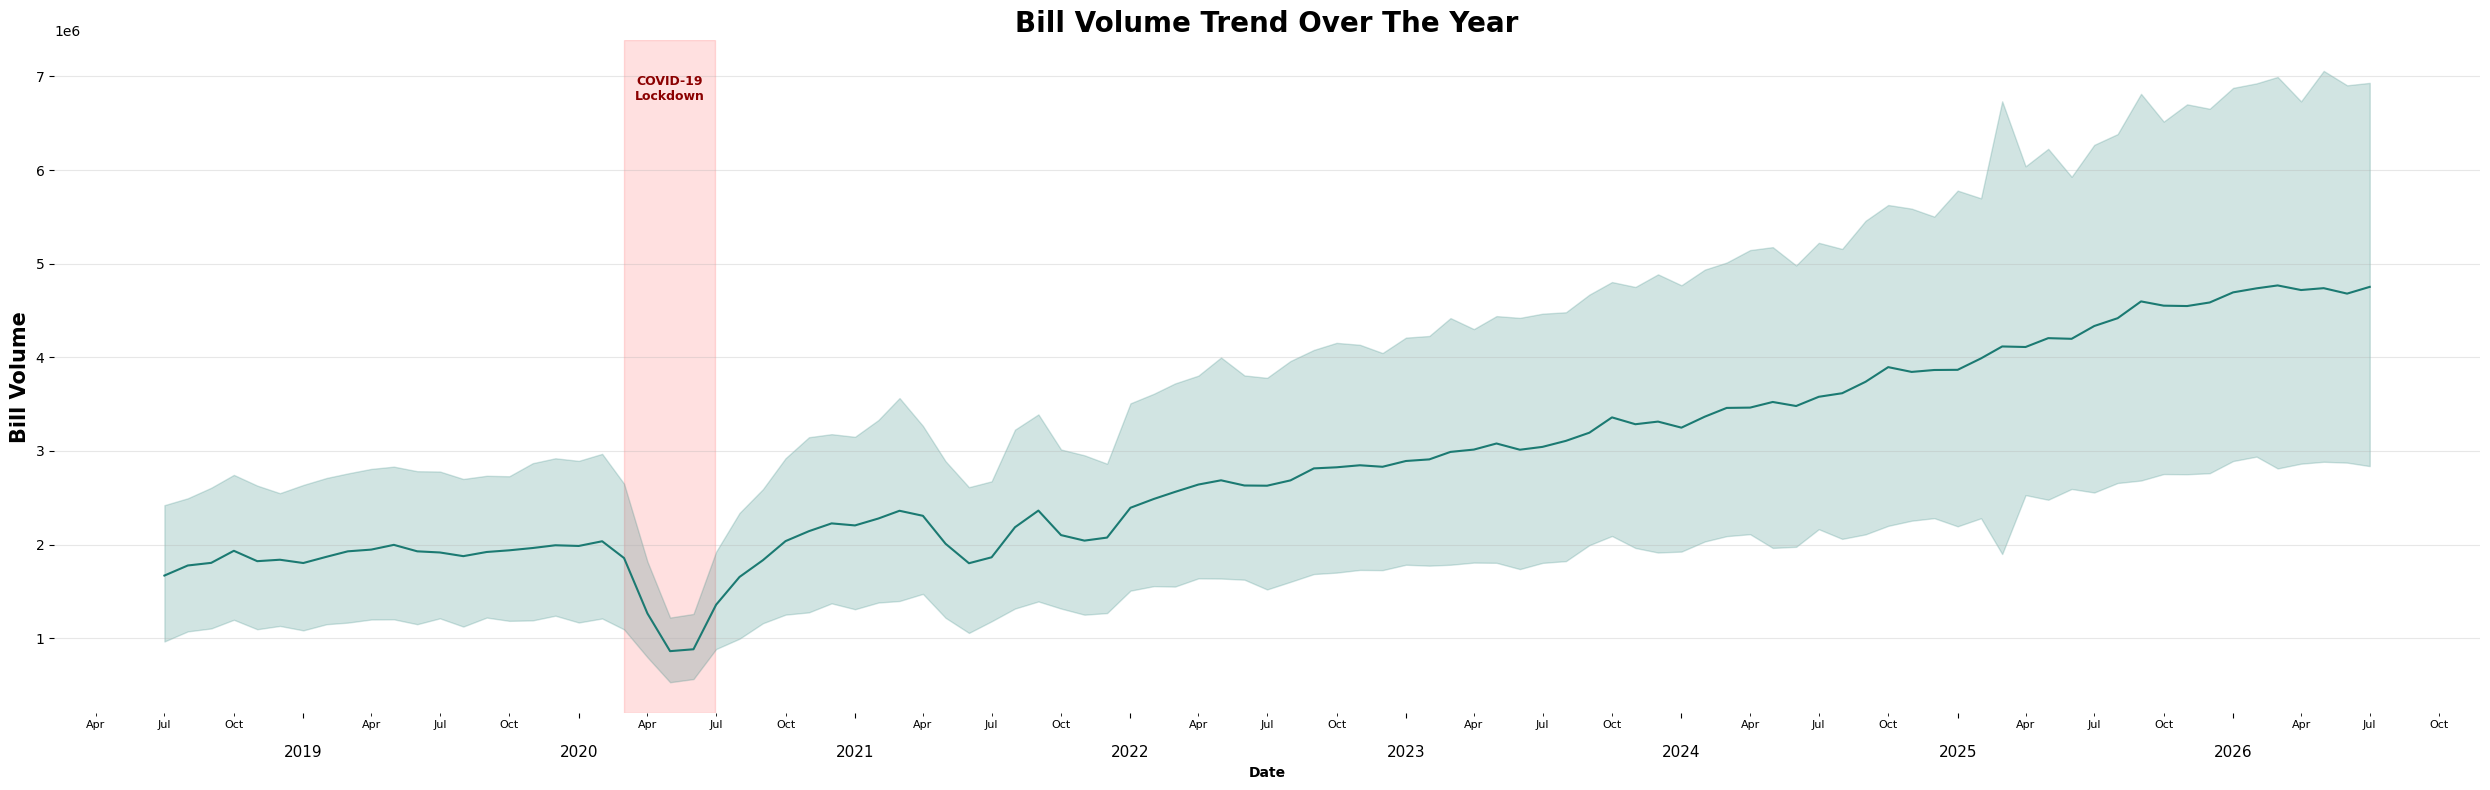

In [29]:
plt.figure(figsize=(25,8))
ax = sns.lineplot(x = 'date',y='avg_bill_3m',data= data,color = '#1B7A72')
ax.set_title("Bill Volume Trend Over The Year",weight = 'bold',fontsize = 20)
plt.xlabel("Date",fontsize = 10, weight = 'bold')
plt.ylabel("Bill Volume",fontsize = 15, weight = 'bold')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# minor ticks = quarters (Jan, Apr, Jul, Oct) — every month gets too cramped
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

# style the two tick levels differently so years stand out
ax.tick_params(axis='x', which='major', labelsize=11, pad=20)
ax.tick_params(axis='x', which='minor', labelsize=8, colors='black')

lockdown_start = pd.Timestamp('2020-03-01')
lockdown_end = pd.Timestamp('2020-06-30')
ax.axvspan(lockdown_start, lockdown_end, color='red', alpha=0.12, zorder=0)
# optional label so it's self-explanatory without a legend entry
ax.text(lockdown_start + (lockdown_end - lockdown_start)/2, ax.get_ylim()[1]*0.95,
        'COVID-19\nLockdown', ha='center', va='top', fontsize=9, color='darkred', weight='bold')

sns.despine(left=True, bottom=True)
ax.grid(axis='y', alpha=0.3)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/bill_volume_trend.png", dpi=150, bbox_inches='tight')
plt.show()

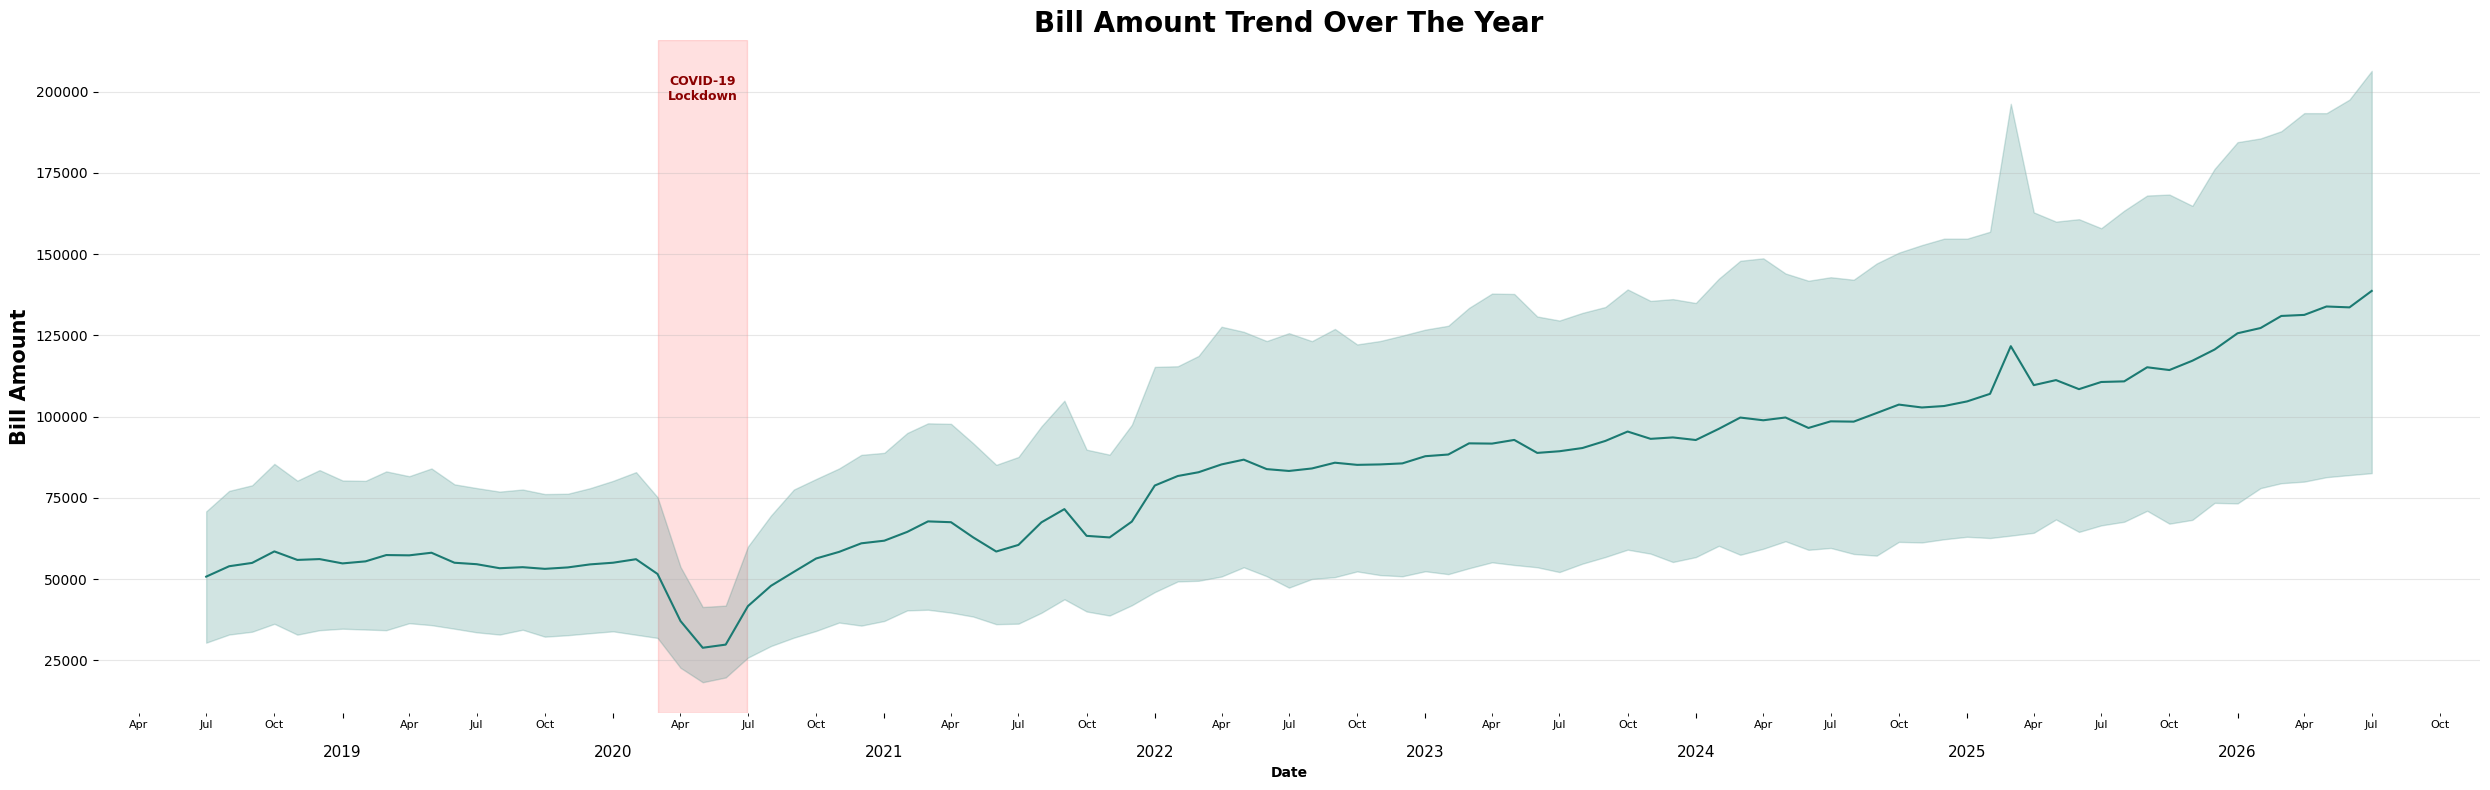

In [30]:
plt.figure(figsize=(25,8))
ax = sns.lineplot(x = 'date',y='avg_amount_3m',data= data,color = '#1B7A72')
ax.set_title("Bill Amount Trend Over The Year",weight = 'bold',fontsize = 20)
plt.xlabel("Date",fontsize = 10, weight = 'bold')
plt.ylabel("Bill Amount",fontsize = 15, weight = 'bold')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# minor ticks = quarters (Jan, Apr, Jul, Oct) — every month gets too cramped
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

# style the two tick levels differently so years stand out
ax.tick_params(axis='x', which='major', labelsize=11, pad=20)
ax.tick_params(axis='x', which='minor', labelsize=8, colors='black')

lockdown_start = pd.Timestamp('2020-03-01')
lockdown_end = pd.Timestamp('2020-06-30')
ax.axvspan(lockdown_start, lockdown_end, color='red', alpha=0.12, zorder=0)
# optional label so it's self-explanatory without a legend entry
ax.text(lockdown_start + (lockdown_end - lockdown_start)/2, ax.get_ylim()[1]*0.95,
        'COVID-19\nLockdown', ha='center', va='top', fontsize=9, color='darkred', weight='bold')

sns.despine(left=True, bottom=True)
ax.grid(axis='y', alpha=0.3)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/bill_amount_trend.png", dpi=150, bbox_inches='tight')
plt.show()